In [50]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib
%pip install soundfile

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



Needed extensions to import:

In [51]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.io import wavfile
from scipy.signal import stft
import matplotlib.pyplot as plt
import soundfile as sf

# 1. Load Data

In [52]:
pattern = os.path.join('data2025', 'Z*', 'Z*', 'Wav', '*.wav')
files = glob.glob(pattern)
print("Gefundene Dateien:", files)

data = []
for fn in files:
    try:
        signal, fs = sf.read(fn)
    except Exception as e:
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue
    basename = os.path.basename(fn)
    parts = basename.split('_')
    entry = {
        'fn': fn,
        'sig': signal,
        'spec': parts[0],
        'mID': parts[1],
        'time': parts[2],
        'rID': parts[3][:3],
        'sID': parts[3].split('.')[0],
        'stft': None
    }
    data.append(entry)

df = pd.DataFrame(data)
print(df.head())

Gefundene Dateien: ['data2025\\Z01\\Z01\\Wav\\Z01_Pos00_1_Ch1.wav', 'data2025\\Z01\\Z01\\Wav\\Z01_Pos00_1_Ch2.wav', 'data2025\\Z01\\Z01\\Wav\\Z01_Pos00_2_Ch1.wav', 'data2025\\Z01\\Z01\\Wav\\Z01_Pos00_2_Ch2.wav', 'data2025\\Z05\\Z05\\Wav\\Z05_Pos01_1_Ch1.wav', 'data2025\\Z05\\Z05\\Wav\\Z05_Pos01_1_Ch2.wav', 'data2025\\Z05\\Z05\\Wav\\Z05_Pos01_2_Ch1.wav', 'data2025\\Z05\\Z05\\Wav\\Z05_Pos01_2_Ch2.wav']
                                         fn  \
0  data2025\Z01\Z01\Wav\Z01_Pos00_1_Ch1.wav   
1  data2025\Z01\Z01\Wav\Z01_Pos00_1_Ch2.wav   
2  data2025\Z01\Z01\Wav\Z01_Pos00_2_Ch1.wav   
3  data2025\Z01\Z01\Wav\Z01_Pos00_2_Ch2.wav   
4  data2025\Z05\Z05\Wav\Z05_Pos01_1_Ch1.wav   

                                                 sig spec    mID time  rID  \
0  [0.00048828125, 0.00244140625, 0.0029296875, 0...  Z01  Pos00    1  Ch1   
1  [0.001953125, 0.0, 0.00146484375, 0.001953125,...  Z01  Pos00    1  Ch2   
2  [0.00146484375, 0.0, 0.00048828125, 0.00195312...  Z01  Pos00    2  Ch1   
3

# 2. STFT-Calculations

In [53]:
for idx, row in df.iterrows():
    fs = 1e6  # Anpassen an reale Abtastrate
    f, t, Zxx = stft(row['sig'], 
                    fs=fs,
                    window='hann',  # Optimierbar [3][4]
                    nperseg=256,    # Fensterlänge
                    noverlap=128)   # 50% Overlap
    
    df.at[idx, 'stft'] = (f, t, np.abs(Zxx))

# 3. Visualization 

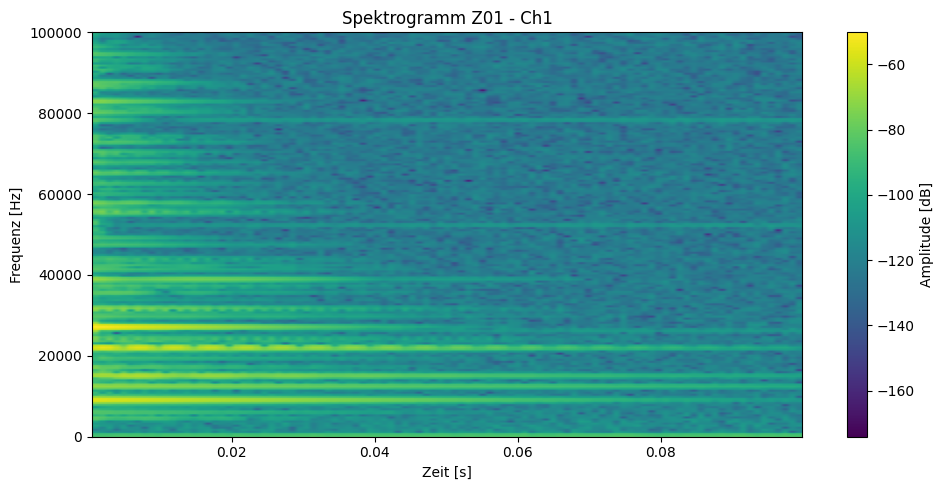

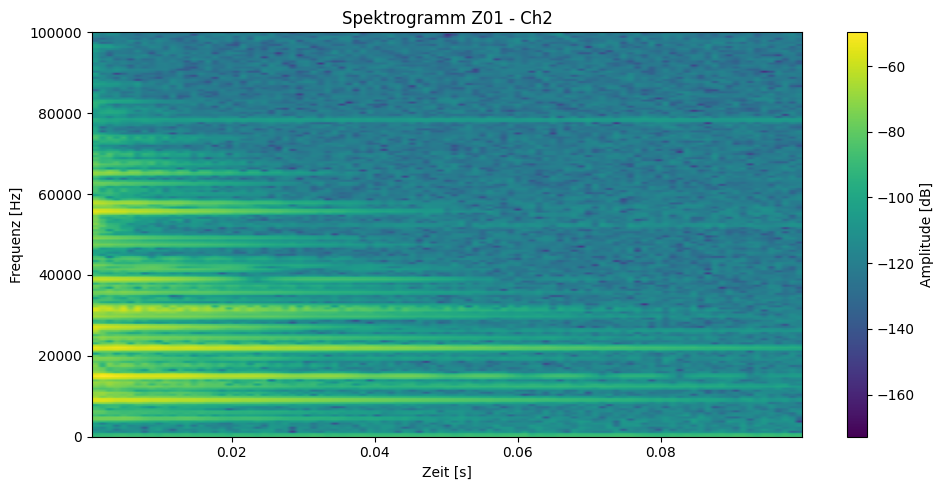

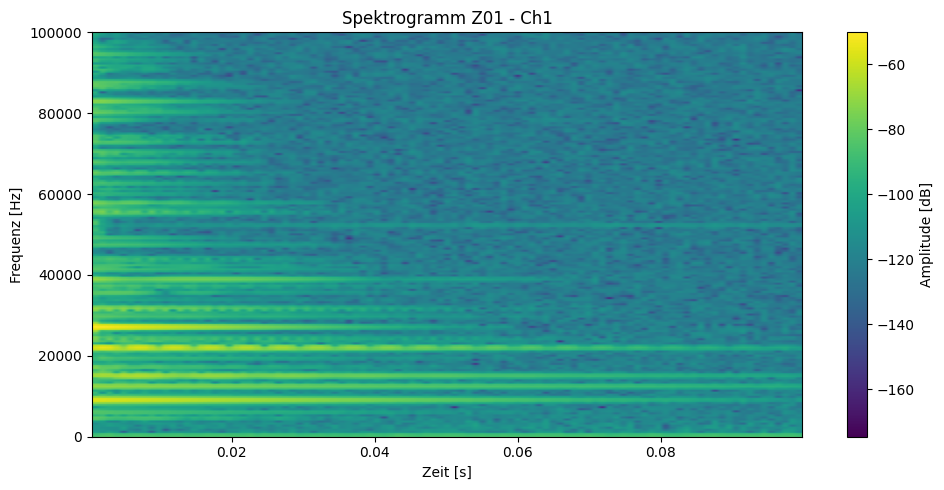

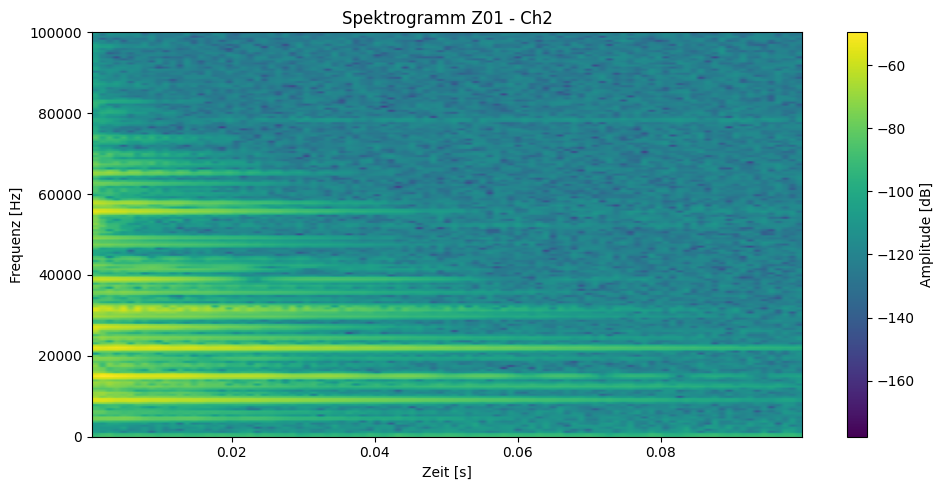

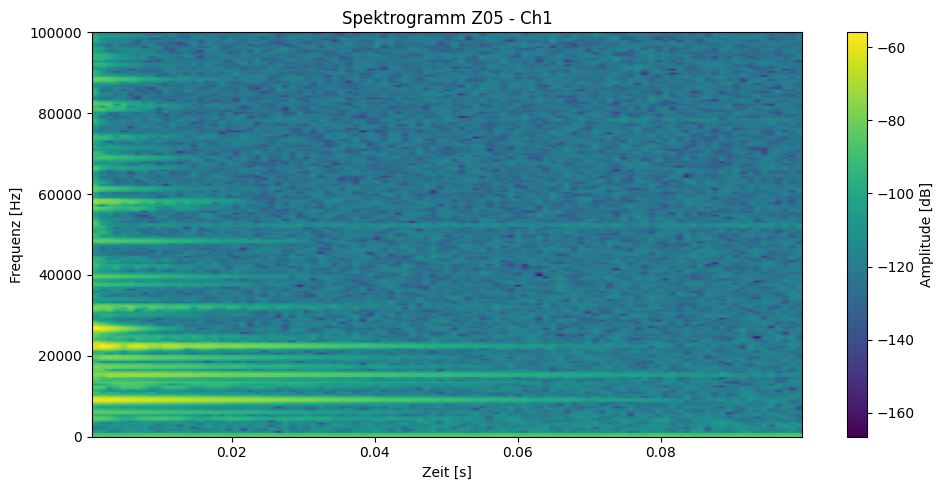

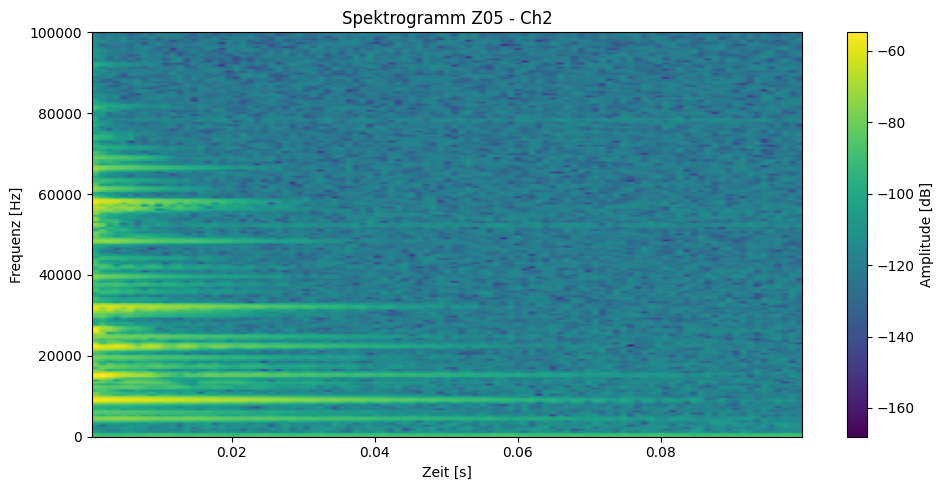

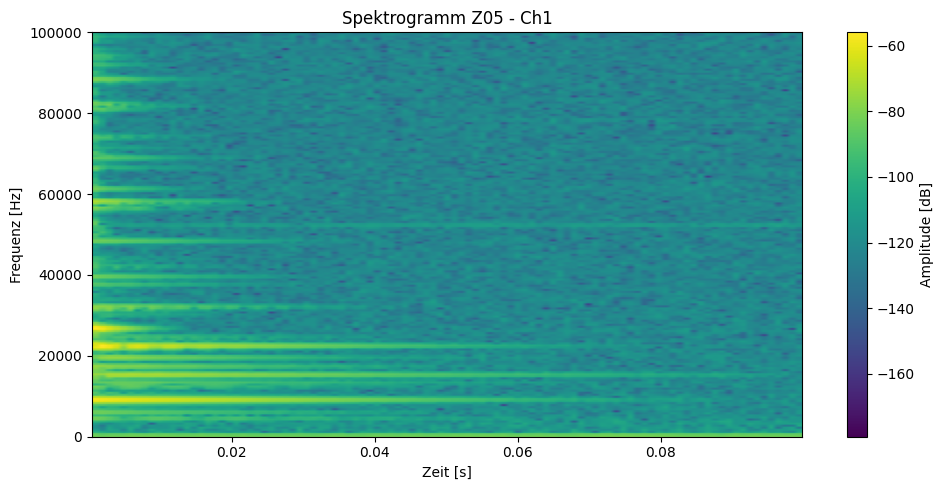

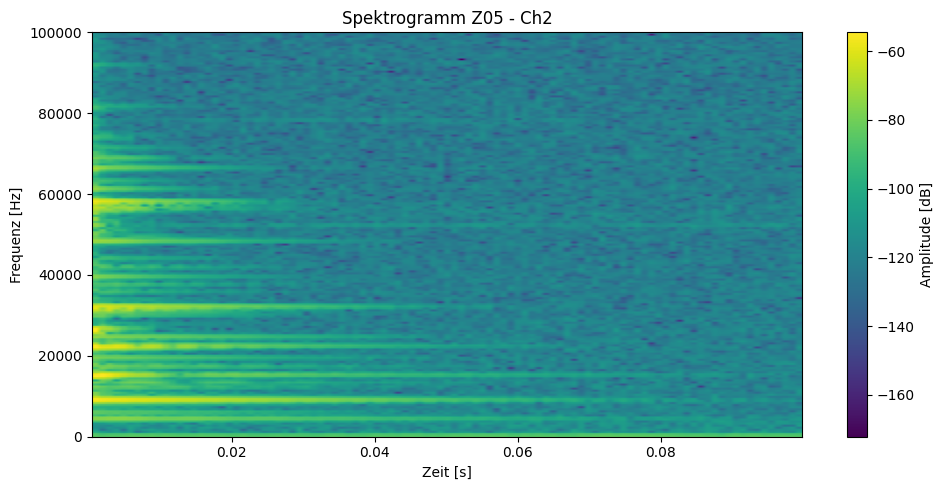

In [ ]:
def plot_spectrogram_signal(row, nfft=2048, noverlap=1024, fmax=100000):
    signal = row['sig']
    fs = row.get('fs', 1041666)  # ggf. anpassen!
    plt.figure(figsize=(10, 5))
    Pxx, freqs, bins, im = plt.specgram(
        signal,
        NFFT=nfft,
        Fs=fs,
        noverlap=noverlap,
        scale='dB',
        cmap='viridis'
    )
    plt.title(f"Spektrogramm {row['spec']} - {row['sID']}")
    plt.ylabel('Frequenz [Hz]')
    plt.xlabel('Zeit [s]')
    plt.ylim(0, fmax)
    plt.colorbar(label='Amplitude [dB]')
    plt.tight_layout()
    plt.show()

for idx, row in df.iterrows():
    plot_spectrogram_signal(row)

# 4. Analysis and Comparison

In [55]:
# Prüfe, wie die Spalten heißen
print("Spalten im DataFrame:", df.columns)

# Falls nötig, passe hier den Spaltennamen an!
def analyze_gear(gear_df):
    avg_power = []
    for _, row in gear_df.iterrows():
        if row['stft'] is not None:
            _, _, Zxx = row['stft']
            avg_power.append(np.mean(Zxx**2))
    if avg_power:
        return np.mean(avg_power)
    else:
        return 0


Spalten im DataFrame: Index(['fn', 'sig', 'spec', 'mID', 'time', 'rID', 'sID', 'stft'], dtype='object')
